In [5]:
import pandas as pd

# Load the supermarket dataset
file_path = "../01_Project-Setup/SUPER MARKET DATA.xlsx"

df = pd.read_excel(file_path)

# Display first 5 rows
df.head()

,Invoice ID,Date,Branch,City,Customer Type,Gender,Product,Category,Quantity,Unit Price,Payment,Rating,Sales
0,INV0001,2026-06-01,A,Jaipur,Member,Male,Milk,Dairy,4,57.13,UPI,3.8,228.52
1,INV0002,2026-02-26,A,Jaipur,Normal,Male,Rice,Grocery,9,66.85,Net Banking,3.9,601.65
2,INV0003,2026-02-09,C,Mumbai,Normal,Female,Milk,Dairy,3,57.28,Card,3.4,171.84
3,INV0004,2026-01-12,C,Mumbai,Member,Female,Shampoo,Personal Care,2,168.27,Card,4.5,336.54
4,INV0005,2026-06-30,A,Jaipur,Normal,Female,Apples,Fruits,5,130.57,Cash,3.1,652.85


In [4]:
%pip install pandas openpyxl

  Using cached numpy-1.24.4-cp38-cp38-win_amd64.whl (14.9 MB)
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
You should consider upgrading via the 'c:\Users\DELL\AppData\Local\Python\pythoncore-3.8-64\python.exe -m pip install --upgrade pip' command.


In [6]:
df.shape

(500, 13)

In [7]:
df.columns

Index(['Invoice ID', 'Date', 'Branch', 'City', 'Customer Type', 'Gender',
       'Product', 'Category', 'Quantity', 'Unit Price', 'Payment', 'Rating',
       'Sales'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Invoice ID     500 non-null    object        
 1   Date           500 non-null    datetime64[ns]
 2   Branch         500 non-null    object        
 3   City           500 non-null    object        
 4   Customer Type  500 non-null    object        
 5   Gender         500 non-null    object        
 6   Product        500 non-null    object        
 7   Category       500 non-null    object        
 8   Quantity       500 non-null    int64         
 9   Unit Price     500 non-null    float64       
 10  Payment        500 non-null    object        
 11  Rating         500 non-null    float64       
 12  Sales          500 non-null    float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(8)
memory usage: 50.9+ KB


In [9]:
df.isnull().sum()

Invoice ID       0
Date             0
Branch           0
City             0
Customer Type    0
Gender           0
Product          0
Category         0
Quantity         0
Unit Price       0
Payment          0
Rating           0
Sales            0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df.describe()


,Date,Quantity,Unit Price,Rating,Sales
count,500,500.000000,500.000000,500.000000,500.000000
mean,2026-04-03 12:25:55.199999744,5.536000,88.660700,3.994400,488.822160
min,2026-01-01 00:00:00,1.000000,27.670000,3.000000,28.610000
25%,2026-02-17 00:00:00,3.000000,43.955000,3.500000,189.212500
50%,2026-04-09 00:00:00,5.500000,61.880000,4.000000,335.910000
75%,2026-05-17 06:00:00,8.000000,128.567500,4.500000,609.885000
max,2026-07-01 00:00:00,10.000000,236.710000,5.000000,2114.820000
std,NaN,2.875629,57.284029,0.574481,437.327833


In [12]:
df["Calculated Sales"] = df["Quantity"] * df["Unit Price"]

(df["Sales"] - df["Calculated Sales"]).abs().max()

4.547473508864641e-13

In [13]:
df["Category"].unique()

array(['Dairy', 'Grocery', 'Personal Care', 'Fruits', 'Vegetables',
       'Snacks', 'Beverages', 'Bakery'], dtype=object)

In [14]:
df["Branch"].unique()

array(['A', 'C', 'B', 'D'], dtype=object)

In [15]:
df["Customer Type"].unique()

array(['Member', 'Normal'], dtype=object)

In [16]:
df["Payment"].unique()

array(['UPI', 'Net Banking', 'Card', 'Cash'], dtype=object)

In [17]:
df["Sales"].sum()

244411.08000000002

In [18]:
df.groupby("Branch")["Sales"].sum().sort_values(ascending=False)

Branch
C    72469.45
B    64116.26
D    55468.29
A    52357.08
Name: Sales, dtype: float64

In [19]:
df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

Category
Beverages        56108.24
Personal Care    45943.96
Dairy            43992.00
Grocery          40470.47
Fruits           23263.17
Snacks           16992.97
Vegetables       11124.17
Bakery            6516.10
Name: Sales, dtype: float64

In [20]:
df["Payment"].value_counts()

Payment
UPI            127
Net Banking    126
Card           125
Cash           122
Name: count, dtype: int64

In [21]:
df.groupby("Customer Type")["Sales"].mean()

Customer Type
Member    483.139527
Normal    497.067549
Name: Sales, dtype: float64

In [22]:
df["Rating"].mean()

3.9943999999999997

In [23]:
df.groupby("Product")["Sales"].sum().sort_values(ascending=False)

Product
Cheese         27906.30
Coffee         27694.87
Shampoo        27497.48
Cooking Oil    21525.06
Tea            17681.59
Apples         17057.41
Face Wash      11946.85
Rice           11754.17
Cold Drink     10731.78
Eggs           10429.77
Chocolate       7250.65
Noodles         7191.24
Potato          6799.38
Bread           6516.10
Soap            6499.63
Bananas         6205.76
Chips           5833.45
Milk            5655.93
Tomato          4324.79
Biscuits        3908.87
Name: Sales, dtype: float64

In [24]:
df.groupby("City")["Sales"].sum().sort_values(ascending=False)

City
Mumbai       72469.45
Delhi        64116.26
Bengaluru    55468.29
Jaipur       52357.08
Name: Sales, dtype: float64

In [25]:
df["Month"] = df["Date"].dt.to_period("M").astype(str)

df.groupby("Month")["Sales"].sum()

Month
2026-01    43415.53
2026-02    30068.15
2026-03    37306.42
2026-04    52569.77
2026-05    42542.31
2026-06    35041.46
2026-07     3467.44
Name: Sales, dtype: float64

In [26]:
df.groupby("Gender")["Sales"].sum().sort_values(ascending=False)

Gender
Female    123954.12
Male      120456.96
Name: Sales, dtype: float64

In [27]:
df.groupby("Customer Type")["Sales"].sum().sort_values(ascending=False)

Customer Type
Member    143009.30
Normal    101401.78
Name: Sales, dtype: float64

In [28]:
df.groupby("Category")["Quantity"].sum().sort_values(ascending=False)

Category
Beverages        465
Snacks           443
Grocery          439
Personal Care    399
Dairy            345
Vegetables       290
Fruits           223
Bakery           164
Name: Quantity, dtype: int64

In [29]:
df.groupby("Category")["Rating"].mean().sort_values(ascending=False)

Category
Bakery           4.242857
Snacks           4.108000
Dairy            4.030882
Vegetables       3.985417
Beverages        3.958537
Personal Care    3.953425
Grocery          3.941463
Fruits           3.829545
Name: Rating, dtype: float64

In [30]:
df.groupby("Product")["Quantity"].sum().sort_values(ascending=False).head(5)

Product
Potato        194
Chips         168
Rice          167
Cold Drink    166
Bread         164
Name: Quantity, dtype: int64

In [31]:
df["Branch"].value_counts()

Branch
C    143
B    133
D    119
A    105
Name: count, dtype: int64

In [32]:
df.groupby("Branch")["Sales"].mean().sort_values(ascending=False)

Branch
C    506.779371
A    498.638857
B    482.077143
D    466.120084
Name: Sales, dtype: float64

In [33]:
df.groupby("Payment")["Sales"].sum().sort_values(ascending=False)

Payment
UPI            67910.33
Net Banking    65194.93
Card           57265.64
Cash           54040.18
Name: Sales, dtype: float64

In [34]:
df.groupby("Product")["Rating"].mean().sort_values(ascending=False).head(5)

Product
Bread        4.242857
Chocolate    4.230435
Milk         4.095455
Chips        4.080769
Eggs         4.030000
Name: Rating, dtype: float64

In [35]:
summary = {
    "Total Sales": df["Sales"].sum(),
    "Average Sales": df["Sales"].mean(),
    "Average Rating": df["Rating"].mean(),
    "Total Quantity Sold": df["Quantity"].sum(),
    "Total Transactions": len(df)
}

pd.Series(summary)

Total Sales            244411.08000
Average Sales             488.82216
Average Rating              3.99440
Total Quantity Sold      2768.00000
Total Transactions        500.00000
dtype: float64

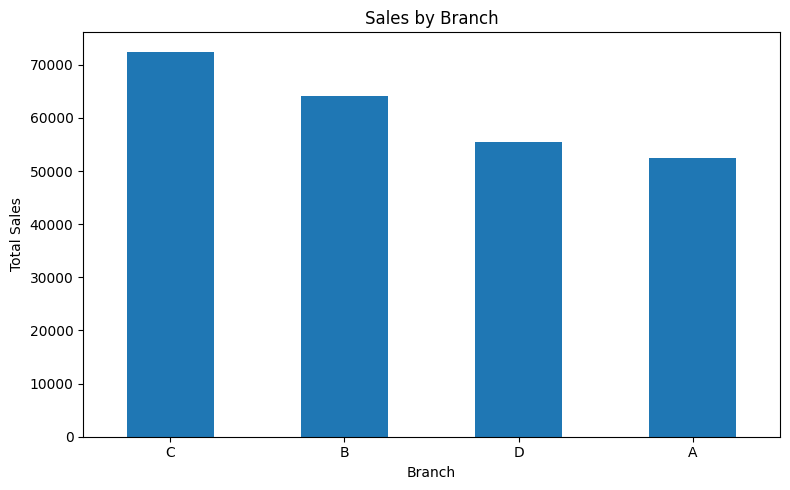

In [38]:
import matplotlib.pyplot as plt

branch_sales = df.groupby("Branch")["Sales"].sum().sort_values(ascending=False)

branch_sales.plot(kind="bar", figsize=(8, 5))

plt.title("Sales by Branch")
plt.xlabel("Branch")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [37]:
%pip install matplotlib

  Using cached pillow-10.4.0-cp38-cp38-win_amd64.whl (2.6 MB)
  Using cached kiwisolver-1.4.7-cp38-cp38-win_amd64.whl (55 kB)
  Using cached pyparsing-3.1.4-py3-none-any.whl (104 kB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
  Using cached importlib_resources-6.4.5-py3-none-any.whl (36 kB)
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
You should consider upgrading via the 'c:\Users\DELL\AppData\Local\Python\pythoncore-3.8-64\python.exe -m pip install --upgrade pip' command.


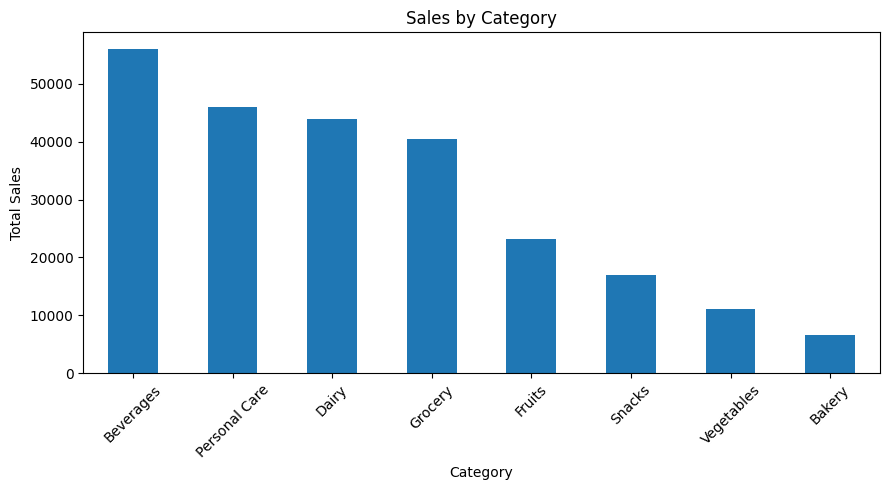

In [39]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

category_sales.plot(kind="bar", figsize=(9, 5))

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

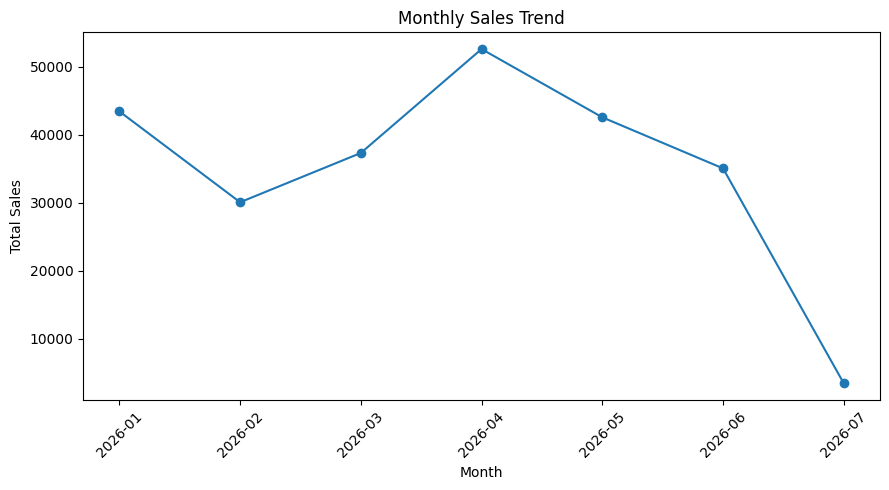

In [40]:
monthly_sales = df.groupby("Month")["Sales"].sum()

monthly_sales.plot(kind="line", marker="o", figsize=(9, 5))

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

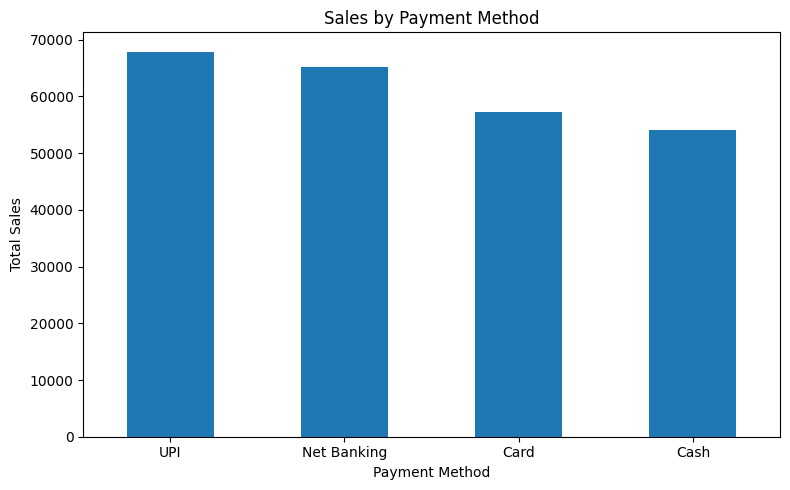

In [41]:
payment_sales = df.groupby("Payment")["Sales"].sum().sort_values(ascending=False)

payment_sales.plot(kind="bar", figsize=(8, 5))

plt.title("Sales by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

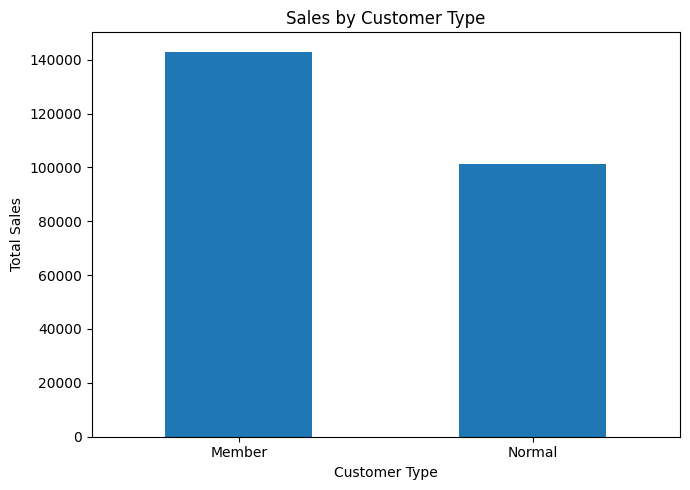

In [42]:
customer_sales = df.groupby("Customer Type")["Sales"].sum().sort_values(ascending=False)

customer_sales.plot(kind="bar", figsize=(7, 5))

plt.title("Sales by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

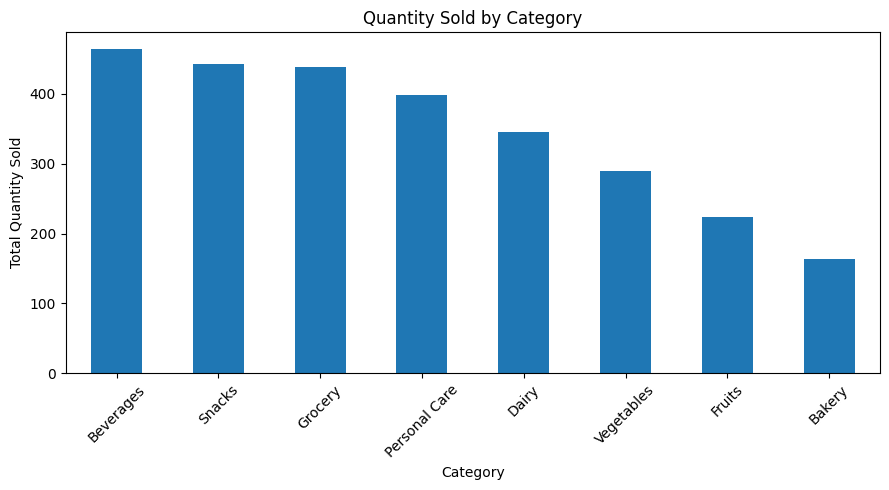

In [43]:
category_quantity = df.groupby("Category")["Quantity"].sum().sort_values(ascending=False)

category_quantity.plot(kind="bar", figsize=(9, 5))

plt.title("Quantity Sold by Category")
plt.xlabel("Category")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

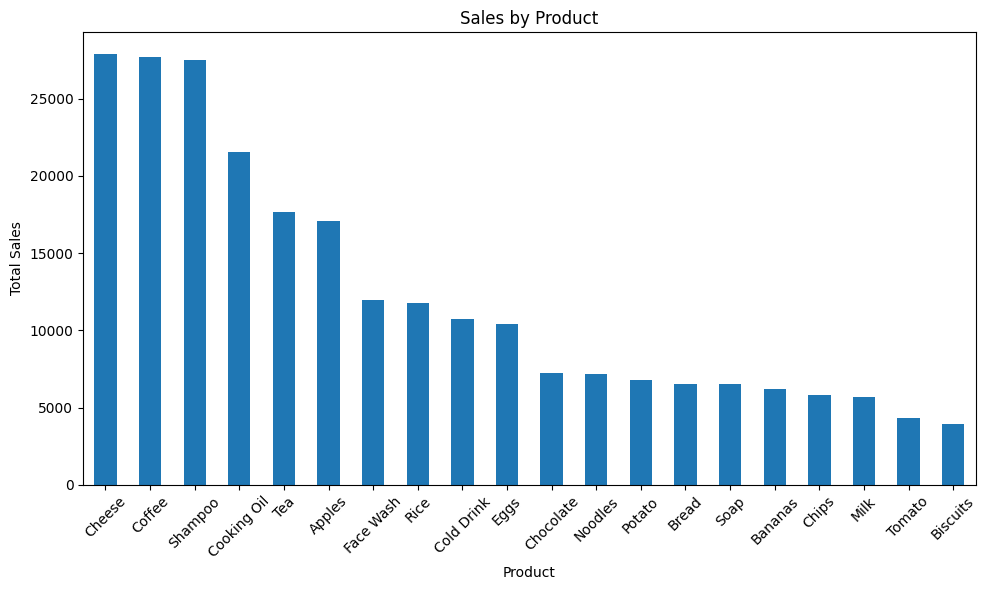

In [44]:
product_sales = df.groupby("Product")["Sales"].sum().sort_values(ascending=False)

product_sales.plot(kind="bar", figsize=(10, 6))

plt.title("Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [45]:
%%markdown

## Key Business Insights

- Branch C (Mumbai) generated the highest total sales of ₹72,469.45.
- Beverages was the highest-selling category with ₹56,108.24 in sales and 465 units sold.
- Cheese was the highest-selling product with ₹27,906.30 in sales.
- UPI was the most-used payment method with 127 transactions and generated the highest payment-method sales of ₹67,910.33.
- Members generated higher total sales (₹143,009.30) than Normal customers (₹101,401.78).
- April 2026 recorded the highest monthly sales of ₹52,569.77.
- Potato had the highest quantity sold among individual products, with 194 units.
- Bakery had the highest category rating at 4.24/5.
- July 2026 shows low sales, but the dataset contains transactions only through July 1, so it should not be interpreted as a complete-month decline.


## Key Business Insights

- Branch C (Mumbai) generated the highest total sales of ₹72,469.45.
- Beverages was the highest-selling category with ₹56,108.24 in sales and 465 units sold.
- Cheese was the highest-selling product with ₹27,906.30 in sales.
- UPI was the most-used payment method with 127 transactions and generated the highest payment-method sales of ₹67,910.33.
- Members generated higher total sales (₹143,009.30) than Normal customers (₹101,401.78).
- April 2026 recorded the highest monthly sales of ₹52,569.77.
- Potato had the highest quantity sold among individual products, with 194 units.
- Bakery had the highest category rating at 4.24/5.
- July 2026 shows low sales, but the dataset contains transactions only through July 1, so it should not be interpreted as a complete-month decline.
